<a href="https://colab.research.google.com/github/sevaradevoloper/machine-learning-class-work/blob/main/39_dars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)  # (7043, 21)
df.dtypes.value_counts()  # aralash: son + matn ustunlar

(7043, 21)


,count
object,18
int64,2
float64,1


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()  # har ustun turi va bo'sh qiymatlar soni

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
(df['TotalCharges'].str.strip() == '').sum()

np.int64(11)

In [ ]:
mask = df['TotalCharges'].str.strip() == ''
df.loc[mask, 'TotalCharges'] = np.nan
df = df.dropna(subset=['TotalCharges'])
print(df.shape)  # (7032, 21)

(7032, 21)


In [ ]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for c in binary_cols:
    df[c] = LabelEncoder().fit_transform(df[c])
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.5,0
7039,2234-XADUH,0,0,1,1,72,1,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,0,0,1,1,11,0,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.6,1


In [ ]:
df['StreamingMovies'].value_counts()

,count
StreamingMovies,
No,2781
Yes,2731
No internet service,1520


In [ ]:
col = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for c in col:
    df[c] = df[c].replace({'No': 0, 'Yes': 1, 'No phone service': 0, 'No internet service':0})

/tmp/ipykernel_44511/315774495.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].replace({'No': 0, 'Yes': 1, 'No phone service': 0, 'No internet service':0})


In [ ]:
multi_cols = ['Contract', 'InternetService', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols)

In [ ]:
num_cols = ['tenure', 'MonthlyCharges',
            'TotalCharges']

In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df.drop('Churn', axis=1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,False,True,False,True,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,False,True,False,True,False,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,False,True,False,True,False,False,False,False,False,True
7039,0,0,1,1,72,1,1,0,1,1,...,False,True,False,False,True,False,False,True,False,False
7040,0,0,1,1,11,0,0,1,0,0,...,True,False,False,True,False,False,False,False,True,False
7041,1,1,1,0,4,1,1,0,0,0,...,True,False,False,False,True,False,False,False,False,True


In [ ]:
df.Churn.value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)
model.score(X_train, y_train), model.score(X_test, y_test)

# pred = (model.predict_proba(X_test)[:,1] >= ).astype(int)

print(confusion_matrix(y_test, pred))
print(accuracy_score(y_test, pred))
print(recall_score(y_test, pred))

[[918 115]
 [161 213]]
0.8038379530916845
0.56951871657754


Accuracy score, recall, precition, F1, confution metrics qaytaruvchi funksiya yozing

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

def acc(y_true, y_pred):
    print('Accuracy:', accuracy_score(y_true, y_pred))
    print('Precision:', precision_score(y_true, y_pred))
    print('Recall:', recall_score(y_true, y_pred))
    print('F1 score:', f1_score(y_true, y_pred))
    print('ROC AUC score:', roc_auc_score(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("==============================")
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d')
    plt.show()

Accuracy: 0.8038379530916845
Precision: 0.649390243902439
Recall: 0.56951871657754
F1 score: 0.6068376068376068
ROC AUC score: 0.7290962411542105
[[918 115]
 [161 213]]


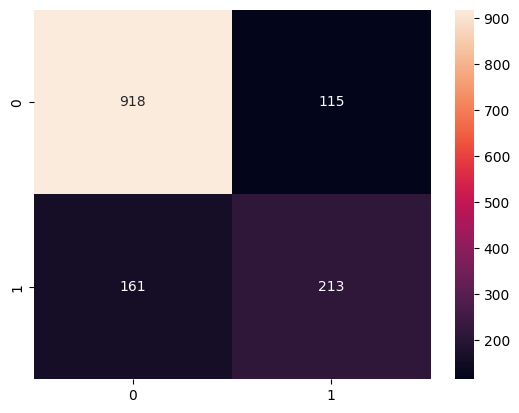

In [ ]:
acc(y_test, pred)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5,
                              random_state=42)

tree.fit(X_train, y_train)  # scaling shart emas

tree.score(X_train, y_train), tree.score(X_test, y_test)
# tree_pred = tree.predict(X_test)
# acc(y_test, tree_pred)
# print(tree.get_n_leaves())

(0.8001777777777778, 0.7874911158493249)

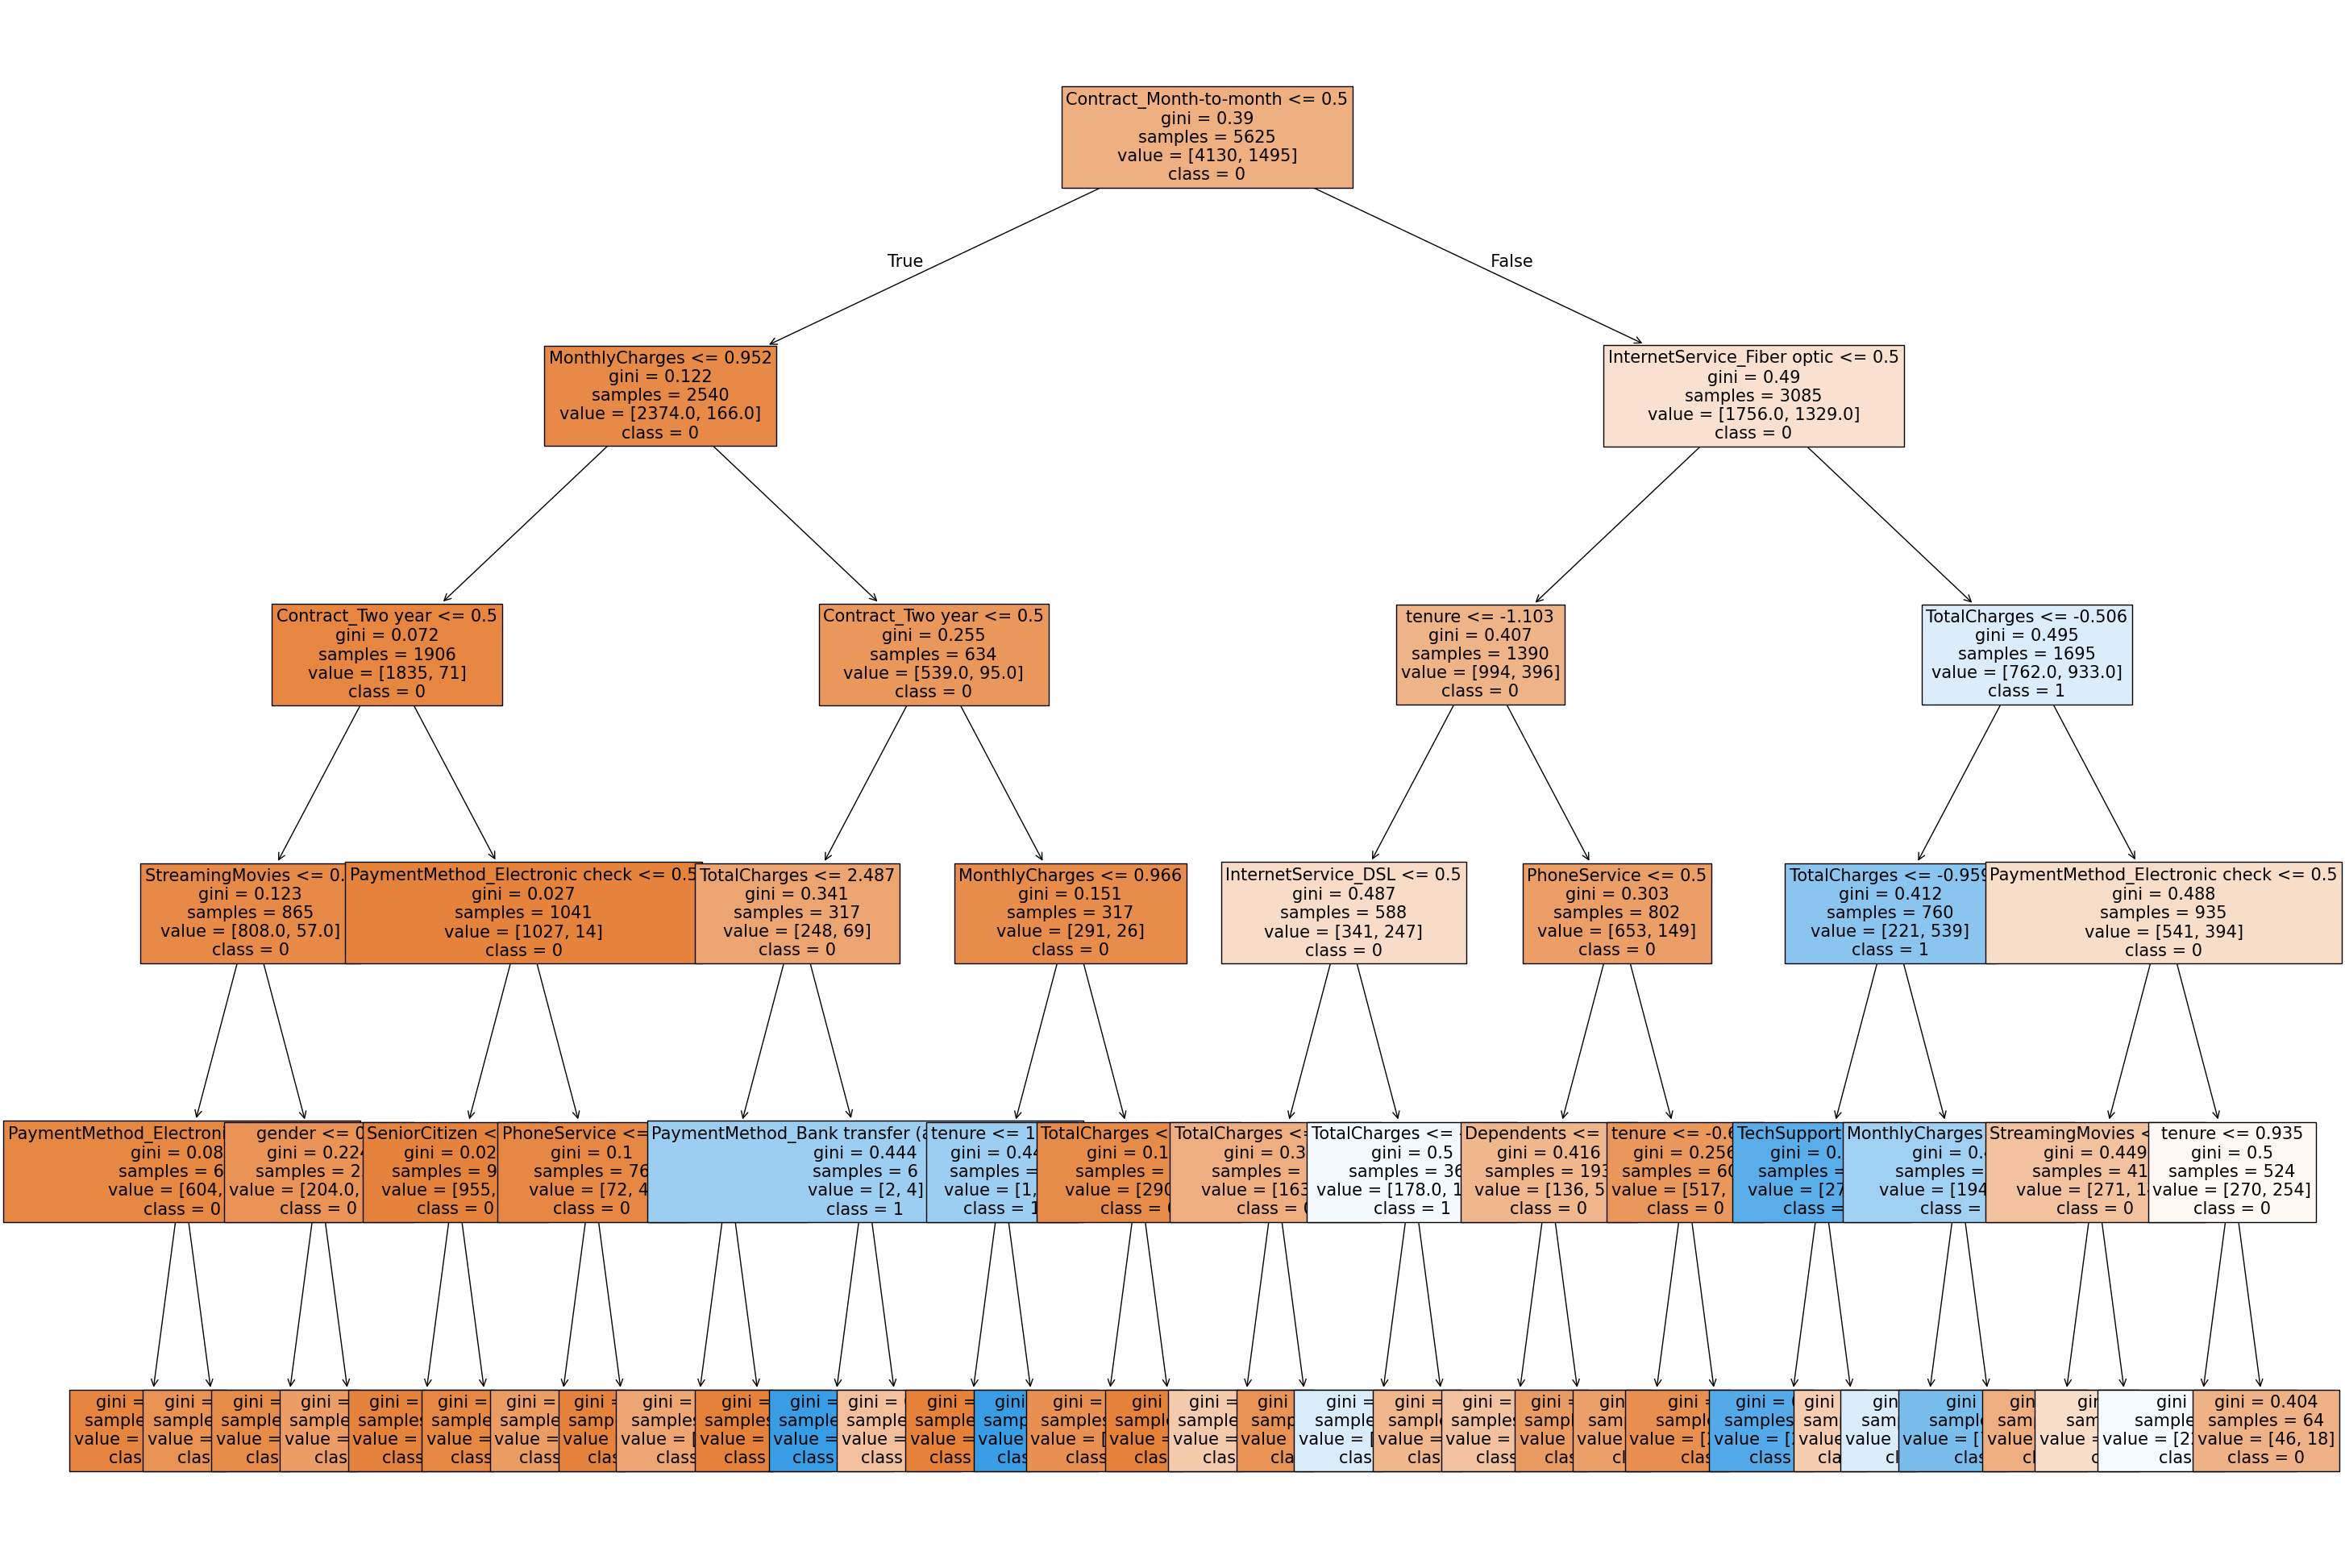

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize = (35, 25))
plot_tree(tree, filled=True, feature_names=X_train.columns, class_names=['0', '1'], fontsize=15)
plt.show()

In [ ]:
# from sklearn.model_selection import GridSearchCV

# grid = {
#     'max_depth': range(1, 10, 2),
#     'min_samples_split': range(2, 10,2),
#     'min_samples_leaf': range(1, 5, 2),
#     'criterion': ['gini', 'entropy'],
#     'max_leaf_nodes': range(1, 10,2)
# }

# gs = GridSearchCV(DecisionTreeClassifier(random_state=42), grid, cv=5, n_jobs=-1)
# gs.fit(X_train, y_train)
# gs.best_params_

Accuracy: 0.7853589196872779
Precision: 0.5957446808510638
Recall: 0.5989304812834224
F1 score: 0.5973333333333334
ROC AUC score: 0.725893120602989
[[881 152]
 [150 224]]


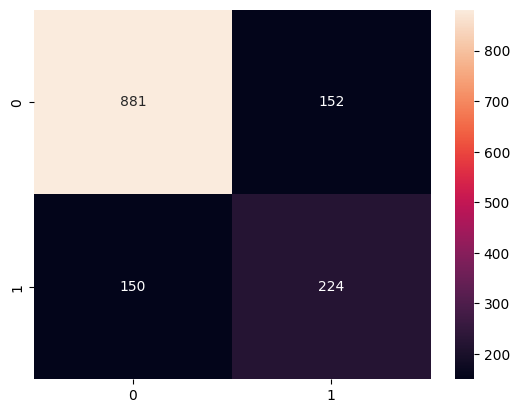

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 31, 2), 'p': [1, 2],
                         'weights': ['uniform', 'distance']})

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train, y_train)

knn.score(X_train, y_train), knn.score(X_test, y_test)
knn_pred = knn.predict(X_test)

acc(y_test, knn_pred)

grid = {
    'n_neighbors': range(1, 31,2),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

gs = GridSearchCV(KNeighborsClassifier(), grid, cv=5, n_jobs=-1)
gs.fit(X_train, y_train)

In [ ]:
print(gs.best_params_)
print(gs.best_score_)
gs.best_estimator_.score(X_train, y_train), gs.best_estimator_.score(X_test, y_test)

{'n_neighbors': 25, 'p': 1, 'weights': 'uniform'}
0.7896888888888889


(0.8088888888888889, 0.7810945273631841)

Accuracy: 0.7874911158493249
Precision: 0.6595744680851063
Recall: 0.4144385026737968
F1 score: 0.5090311986863711
ROC AUC score: 0.6684970828954657
[[953  80]
 [219 155]]


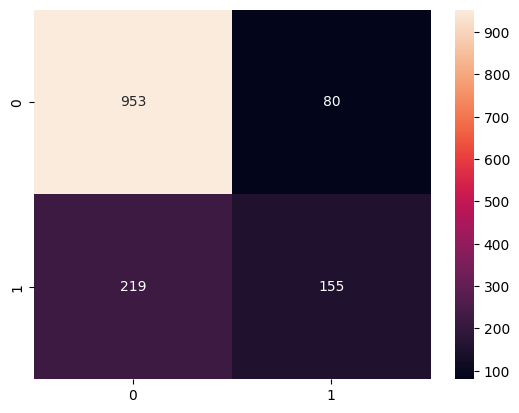

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, max_depth=5)
rf.fit(X_train, y_train)  # scaling shart emas

rf.score(X_train, y_train), rf.score(X_test, y_test)
acc(y_test, rf.predict(X_test))

In [ ]:
# grid = {
#     'n_estimators': range(100, 300, 50),
#     'max_depth': range(1, 10, 2),
#     'min_samples_split': range(2, 10,2),
#     'min_samples_leaf': range(1, 5, 2),
#     'criterion': ['gini', 'entropy'],
#     'max_leaf_nodes': range(1, 10,2)
# }


# gs = GridSearchCV(RandomForestClassifier(random_state=42), grid, cv=5, n_jobs=-1)
# gs.fit(X_train, y_train)
# print(gs.best_params_)
# print(gs.best_score_)
# gs.best_estimator_.score(X_train, y_train), gs.best_estimator_.score(X_test, y_test)

In [ ]:
pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

,0
Contract_Month-to-month,0.220502
tenure,0.183494
InternetService_Fiber optic,0.116962
TotalCharges,0.085871
PaymentMethod_Electronic check,0.071115
MonthlyCharges,0.067252
Contract_Two year,0.063977
InternetService_No,0.042127
Contract_One year,0.022582
InternetService_DSL,0.021487


In [ ]:
from sklearn.svm import SVC

svc = SVC(kernel='linear', C=0.5)
svc.fit(X_train, y_train)

svc.score(X_train, y_train), svc.score(X_test, y_test)

(0.8016, 0.7974413646055437)

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
def cross(model, X, y):
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print(cross_val_score(model, X, y, cv=5).mean())

cross(LogisticRegression(max_iter=1000, random_state=42), X, y)

0.8041799739364548
